In [1]:
# Imports.
import numpy as np;
import os;
import glob;
import pandas as pd;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
BASE_PATH = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_9.0";
PREFIX = "DN_QSCAN_RECTEST";
effective_radius = 0.7

In [3]:
def parameter_scan_relaxation_analysis_phi2D(base_directory, folder_prefix, dt_diag, effective_radius, residual_window = 100, signal_band_pass = True):

	# This method presumes we process parameter scans, in the same vein as `parameter_scan_analysis_phi2D`.
	# `folder_prefix` should be of the form "DN_*_*_[parameter value]" (DN is the standard GYSELA format, not necessarily invoked here).
	search_pattern = os.path.join(base_directory, f"{folder_prefix}_*");
	# Match search pattern, return list in ascending order.
	matching_directories = sorted(glob.glob(search_pattern));

	if not matching_directories:

		print(f"No directories found matching pattern: {search_pattern}");
		return;

	results = [];

	for directory in matching_directories:

		folder_basename = os.path.basename(directory);
		# Split the folder name, taking the last entry as that corresponding to the parameter value.
		parameter_value_string = folder_basename.split("_")[-1];
		parameter_value = float(parameter_value_string);
		print(f"Processing {folder_basename} with parameter value: {parameter_value}");

		phi2D_list = reader.fetch_phi2D_data(directory);
		delta_t = reader.fetch_delta_t(directory);
		# Signal isolation and data processing.
		radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, effective_radius);

		if signal_band_pass:
			radial_time_series = utils.butterworth_band_pass_filter(radial_time_series, dt_diag);

		# We recover the actual number of simulation time-steps here.
		# This does not actually change the size of the array, only its spacing.
		time_range = utils.generate_time_range_by_series(radial_time_series, delta_t, dt_diag);
		GAM_frequency = utils.extract_gam_frequency(phi2D_list, dt_diag, effective_radius);
		amplitude_envelope = utils.generate_damping_envelope(radial_time_series, GAM_frequency, dt_diag);
		residual_level = utils.calculate_residual_level(amplitude_envelope, residual_window);

		if signal_band_pass:
			# Restore residual levels as the band-pass eliminates this information.
			radial_time_series += residual_level;
			amplitude_envelope += residual_level;

		results.append({
			"time_range": time_range,
			"signal": radial_time_series,
			"gam_frequency": GAM_frequency,
			"gam_envelope": amplitude_envelope,
			"residual_level": residual_level,
			"folder_name": folder_basename
		})

	dataframe_results = pd.DataFrame(results);
	return dataframe_results;

In [ ]:
def plot_parameter_scan_relaxation(dataframe, effective_radius = 0.7, n_columns = 2, parameter_label = "param"):

	n_runs = len(dataframe);
	n_columns = min(n_columns, n_runs);
	n_rows = int(np.ceil(n_runs / n_columns));

	fig = plt.figure(figsize = (10 * n_columns, 5 * n_rows));
	gs = fig.add_gridspec(n_rows, n_columns, hspace = 0.45, wspace = 0.3);

	for index, row in dataframe.iterrows():

		row_index = index // n_columns;
		column_index = index % n_columns;
		ax = fig.add_subplot(gs[row_index, column_index]);

		parameter_value = row["folder_name"].split("_")[-1];
		signal = row["signal"];
		time_range = row["time_range"];
		gam_envelope = row["gam_envelope"];
		residual_level = row["residual_level"];
		gam_frequency = row["gam_frequency"];

		ax.plot(time_range, gam_envelope, color = "black", linestyle = "--", label = "Damping envelope", lw = 2.0);
		ax.plot(time_range, signal, color = "firebrick", label = "Signal", lw = 2.5);
		ax.axhline(y = residual_level, color = "gray", linestyle = ":", label = "RH residual", lw = 2.5);
		ax.set_xlabel("t [GYSELA timestep]");
		ax.set_ylabel(r"$\langle \Phi \rangle_\theta$");
		ax.set_title(f"{parameter_label} = {parameter_value}, $\\rho$ = {effective_radius}");
		ax.legend(frameon = True, loc = "lower right");

	# Hide any unused axes in the grid.
	for unused_index in range(n_runs, n_rows * n_columns):
		fig.add_subplot(gs[unused_index // n_columns, unused_index % n_columns]).set_visible(False);

	fig.suptitle(f"GAM damping & RH residual relaxation — parameter scan, {parameter_label}", fontsize = 14);
	plt.tight_layout();
	plt.show();

Processing DN_QSCAN_RECTEST_1.5 with parameter value: 1.5
Found 2001 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Compiled data from 2000 files...
Finished compiling data from all files in the directory.
Processing DN_QSCAN_RECTEST_2.5 with parameter value: 2.5
Found 2001 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Compiled data from 2000 files...
Finished compiling data from all files in the directory.
Processing DN_QSCAN_RECTEST_3.5 with parameter value: 3.5
Found 2001 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Compiled data from 2000 files...
Finished compiling data from all files in the directory.


/tmp/ipykernel_2527501/604449993.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout();


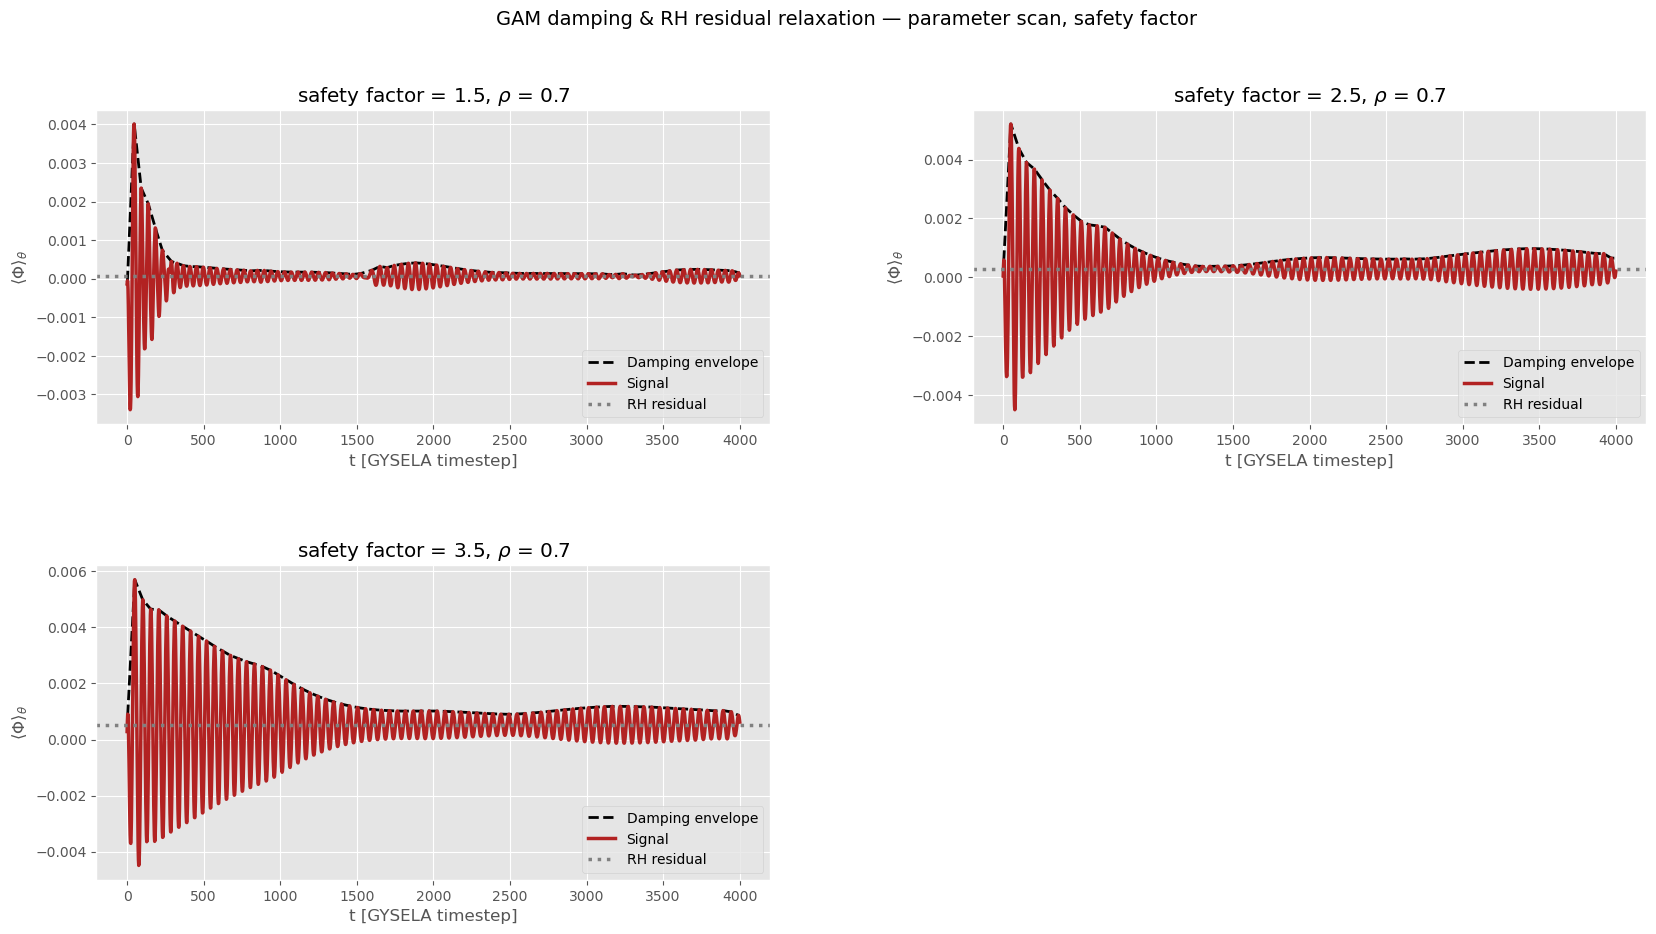

In [5]:
dataframe = parameter_scan_relaxation_analysis_phi2D(BASE_PATH, PREFIX, dt_diag = 50, effective_radius = effective_radius, residual_window = 30, signal_band_pass = True);
plot_parameter_scan_relaxation(dataframe, parameter_label = "safety factor");